# Proyecto Interacción con API del World Bank

Paises: ARG, BRA, CHL, MEX, COL

Indicadores: 
- NY.GDP.PCAP.CD (PIB per cápita)
- SP.DYN.LEE00.IN (Esperanza de vida)
- EN.ATM.CO2E.PC(CO2 per cápita)

Rango: 2010-2014

In [16]:
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

Descargando la Data 

In [17]:

BASE_URL = "https://api.worldbank.org/v2"

countries = ["ARG", "BRA", "CHL", "COL", "MEX"]

indicators = {
    "NY.GDP.PCAP.CD": "GDP per capita",
    "SP.DYN.LE00.IN": "Life expectancy",
    "EN.GHG.CO2.PC.CE.AR5": "CO2 per capita"
}



In [18]:
url_test = f"{BASE_URL}/country"
params_test = {"format": "json", "per_page": 5, "page": 1}

resp_test = requests.get(url_test, params=params_test, timeout=30)
resp_test.raise_for_status()
payload_test = resp_test.json()

print("Metadatos:", payload_test[0])
print("Primer elemento:", payload_test[1][0])

Metadatos: {'page': 1, 'pages': 59, 'per_page': '5', 'total': 295}
Primer elemento: {'id': 'ABW', 'iso2Code': 'AW', 'name': 'Aruba', 'region': {'id': 'LCN', 'iso2code': 'ZJ', 'value': 'Latin America & Caribbean '}, 'adminregion': {'id': '', 'iso2code': '', 'value': ''}, 'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'}, 'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'}, 'capitalCity': 'Oranjestad', 'longitude': '-70.0167', 'latitude': '12.5167'}


In [19]:
country_str = ";".join(countries)
all_data = []

for code, name in indicators.items():
    url = f"{BASE_URL}/country/{country_str}/indicator/{code}"
    params = {
        "format": "json",
        "date": "2010:2024",
        "per_page": 1000
    }
    response = requests.get(url, params=params, timeout=30)
    response.raise_for_status()
    payload = response.json()

    records = payload[1]
    if records is None:
        print(f"Sin datos para {code}")
        continue

    for r in records:
        all_data.append({
            "country": r["country"]["value"],
            "country_code": r["countryiso3code"],
            "indicator": name,
            "year": int(r["date"]),
            "value": r["value"]
        })

print(f"Total de registros descargados: {len(all_data)}")

Total de registros descargados: 225


### Construcción y limpieza de DataFrame por indicador 

In [20]:
df = pd.DataFrame(all_data)

print("Antes de limpiar:", df.shape)
df = df.dropna(subset=["value"])
df = df.sort_values(["indicator", "country", "year"]).reset_index(drop=True)
print("Después de limpiar:", df.shape)

df.head(10)

Antes de limpiar: (225, 5)
Después de limpiar: (225, 5)


,country,country_code,indicator,year,value
0,Argentina,ARG,CO2 per capita,2010,4.294546
1,Argentina,ARG,CO2 per capita,2011,4.429218
2,Argentina,ARG,CO2 per capita,2012,4.478861
3,Argentina,ARG,CO2 per capita,2013,4.536587
4,Argentina,ARG,CO2 per capita,2014,4.416746
5,Argentina,ARG,CO2 per capita,2015,4.512587
6,Argentina,ARG,CO2 per capita,2016,4.422301
7,Argentina,ARG,CO2 per capita,2017,4.321029
8,Argentina,ARG,CO2 per capita,2018,4.250758
9,Argentina,ARG,CO2 per capita,2019,4.075041


### Análisis de Visualizaciones

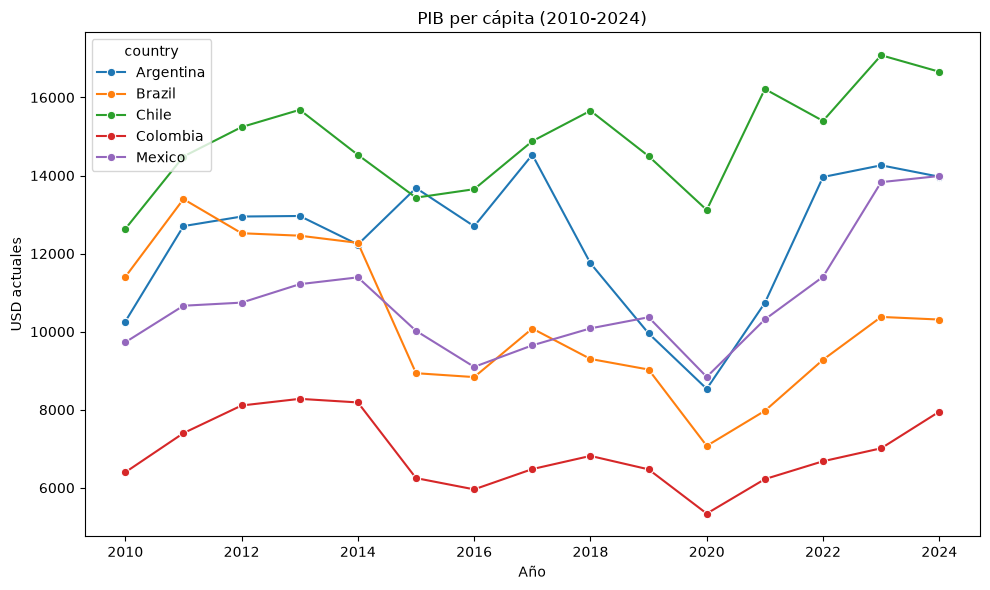

In [21]:
# 1. Evolución del PIB per cápita por país a través del tiempo

plt.figure(figsize=(10, 6))
gdp = df[df["indicator"] == "GDP per capita"]
sns.lineplot(data=gdp, x="year", y="value", hue="country", marker="o")
plt.title("PIB per cápita (2010-2024)")
plt.ylabel("USD actuales")
plt.xlabel("Año")
plt.tight_layout()
plt.show()

Se puede evidenciar como el año 2020 para todos los paises hubo una caida muy significativa, esto es coherente debido a que fué pandemia. El país que se mantiene de manera constante mas alto al resto es Chile.

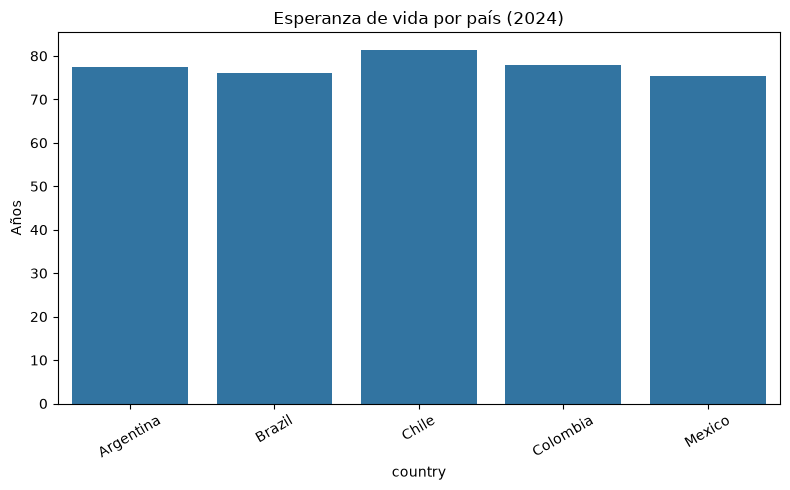

In [22]:
# 2. Comparación de esperanza de vida entre países (último año disponible)

plt.figure(figsize=(8, 5))
life = df[(df["indicator"] == "Life expectancy") & (df["year"] == df["year"].max())]
sns.barplot(data=life, x="country", y="value")
plt.title(f"Esperanza de vida por país ({df['year'].max()})")
plt.ylabel("Años")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

La esperanza de vida para todos los paises se mantiene casi que igual, se puede decir que, esto se debe a que todos los paises hacen parte de Latino america, mismo estilo de vida, politica y socio-cultural. 

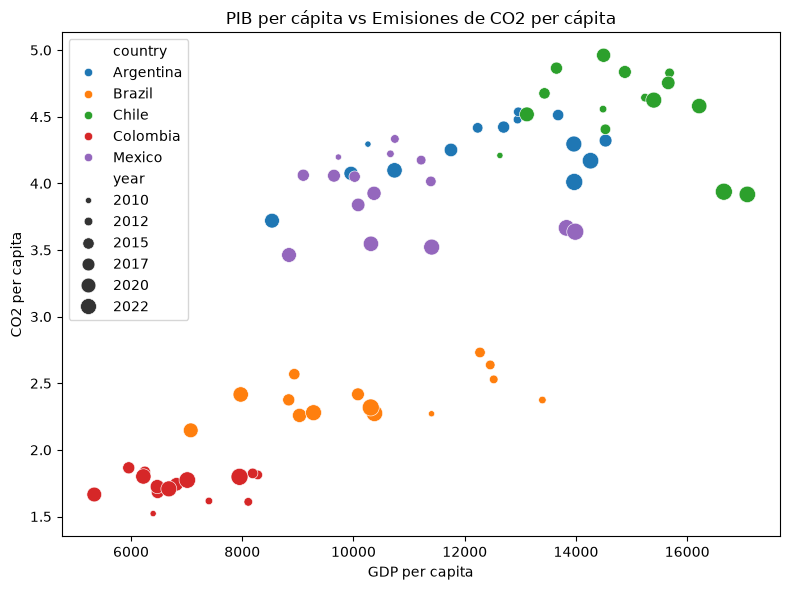

In [23]:
# 3. Relación entre PIB per cápita y emisiones de CO2 (todos los años)

pivot = df.pivot_table(index=["country", "year"], columns="indicator", values="value").reset_index()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pivot, x="GDP per capita", y="CO2 per capita", hue="country", size="year", sizes=(20, 150))
plt.title("PIB per cápita vs Emisiones de CO2 per cápita")
plt.tight_layout()
plt.show()

Carga a SQL

In [24]:
engine = create_engine("sqlite:///worldbank_data.db")
df.to_sql("indicadores", engine, if_exists="replace", index=False)

print("Datos cargados correctamente en worldbank_data.db")

Datos cargados correctamente en worldbank_data.db


In [25]:
df_check = pd.read_sql("SELECT * FROM indicadores LIMIT 10", engine)
df_check

,country,country_code,indicator,year,value
0,Argentina,ARG,CO2 per capita,2010,4.294546
1,Argentina,ARG,CO2 per capita,2011,4.429218
2,Argentina,ARG,CO2 per capita,2012,4.478861
3,Argentina,ARG,CO2 per capita,2013,4.536587
4,Argentina,ARG,CO2 per capita,2014,4.416746
5,Argentina,ARG,CO2 per capita,2015,4.512587
6,Argentina,ARG,CO2 per capita,2016,4.422301
7,Argentina,ARG,CO2 per capita,2017,4.321029
8,Argentina,ARG,CO2 per capita,2018,4.250758
9,Argentina,ARG,CO2 per capita,2019,4.075041
